# Entitiy Resolution PoC

Dieser PoC beschäftigt sich mit Entity Resolution (ER) mit Matryoshka Embeddings von `jina-embeddings-v4` und Hierarchical Navigable Small World (HNSW) für die ANN Suche als zu grunde liegende Technologien. Ziel ist die Maximierung der Konsistenz von oft unsauberen Daten.

Jina AI verwendet in ihren Modellen das Matryoshka Prinzip nach Kusupati et al. (2022). Hierbei werden verschiedene "Dimensionsstufen" in die Loss-Funktion eines Modells eingearbeitet:
$$
\mathcal{L}_{MRL}=∑_{m∈M}c_m⋅\mathcal{L} ⁣(f^{(m)}(x), y)
$$

| Symbol | Bedeutung |
|--------|-----------|
| $\mathcal{M}$ | Menge der Nested-Dimensionen, z.B. $\{128, 256, 512, 1024, 2048\}$ |
| $m$ | Eine konkrete Dimension $m \in \mathcal{M}$ |
| $c_m$ | Gewicht für Dimension $m$ (oft $c_m = 1 \ \forall m$) |
| $f^{(m)}(x)$ | Erste $m$ Dimensionen des vollen Embeddings $f(x) \in \mathbb{R}^d$ |
| $\mathcal{L}$ | Basis-Loss (z.B. InfoNCE / Contrastive Loss) |

## Setup

In [1]:
import time
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from helper import setup_environment, setup_device, make_faiss_index, print_environment_info


in_kaggle = setup_environment()
DEVICE = setup_device()
print_environment_info(in_kaggle, DEVICE)

Python:       /Users/finnhertsch/projects/entity-res/.venv/bin/python
transformers: 4.57.6
Environment : Local
Device      : mps


## Synthetische Datenerstellung

In [2]:
from DataProvider import data_generator
from IPython.display import display

def generate_data(n):
    df_base = data_generator.generate_base_data(n=n)
    df_noisy = data_generator.generate_noisy_duplicates(df_base)
    print(f"Generated: {len(df_base)} originals, {len(df_noisy)} noisy duplicates.")
    return df_base, df_noisy


def highlight_differences(df_base, df_noisy, n_samples=10):
    base_sample = df_base.head(n_samples).reset_index(drop=True)
    noisy_sample = df_noisy.head(n_samples).reset_index(drop=True)

    shared_cols = [c for c in base_sample.columns if c in noisy_sample.columns]
    diff_mask = base_sample[shared_cols] != noisy_sample[shared_cols]

    def style_base(row):
        return ["background-color: #d4edda; color: #155724"] * len(row)

    def style_noisy(data):
        styles = pd.DataFrame("", index=data.index, columns=data.columns)
        for col in diff_mask.columns:
            if col in data.columns:
                styles.loc[diff_mask[col], col] = "background-color: #f8d7da; color: #721c24; font-weight: bold"
        return styles

    styled_base = (
        base_sample[shared_cols]
        .style.apply(style_base, axis=1)
        .set_caption("Base Records")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )

    styled_noisy = (
        noisy_sample[shared_cols]
        .style.apply(style_noisy, axis=None)
        .set_caption("Noisy Duplicates  (red = changed field)")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )

    display(styled_base)
    display(styled_noisy)
    return diff_mask


def show_diff_summary(diff_mask):
    summary = diff_mask.sum().rename("Changed Fields").to_frame()
    summary["Change Rate"] = (diff_mask.mean() * 100).round(1).astype(str) + "%"
    summary = summary[summary["Changed Fields"] > 0].sort_values("Changed Fields", ascending=False)

    display(
        summary.style
        .background_gradient(subset=["Changed Fields"], cmap="Reds")
        .set_caption("📊 Diff Summary (first 10 pairs)")
    )


def show_side_by_side_pair(df_base, df_noisy, idx=0):
    shared_cols = [c for c in df_base.columns if c in df_noisy.columns]
    row_base = df_base.iloc[idx][shared_cols]
    row_noisy = df_noisy.iloc[idx][shared_cols]

    comparison = pd.DataFrame({"Base": row_base, "Noisy": row_noisy})
    comparison["Changed"] = comparison["Base"] != comparison["Noisy"]

    display(
        comparison.style
        .apply(lambda row: [
            "", "",
            "color: red; font-weight: bold" if row["Changed"] else "color: green"
        ], axis=1)
        .set_caption(f"Record pair at index {idx}")
    )


df_base, df_noisy = generate_data(n=1_000)
diff_mask = highlight_differences(df_base, df_noisy, n_samples=10)
show_diff_summary(diff_mask)
show_side_by_side_pair(df_base, df_noisy, idx=0)

Generated: 1000 originals, 1000 noisy duplicates.


,text
0,"Dowerg | Henschelplatz 218, Backnang | Industrie-Zentrifuge"
1,"Davids AG & Co. OHG | Camilla-Gumprich-Allee 4-8, Altötting | OsciJet Fluidik-Oszillator"
2,"Thanel GmbH & Co. KG | Försterplatz 71/21, Ilmenau | OsciJet Fluidik-Oszillator"
3,"Hettner | Reisinggasse 2-9, Sebnitz | Industrie-Zentrifuge"
4,"Klotz | Bartholomäus-Speer-Platz 2/4, Konstanz | Laborabzug Pro X"
5,"Metz Schuster GmbH | Klappplatz 2/3, Eberswalde | Abfüllanlage Type 3"
6,"Kramer Hiller KGaA | Wilmsenallee 3, Herford | Abfüllanlage Type 3"
7,"Heuser Bolzmann AG & Co. OHG | Gerdi-Ortmann-Straße 32-44, Wolfratshausen | Abfüllanlage Type 3"
8,"Lorch | Hartmannplatz 21-30, Tecklenburg | Industrie-Zentrifuge"
9,"Schenk Bolnbach GmbH | Rädelring 1, Sondershausen | OsciJet Fluidik-Oszillator"


,text
0,"Dowerg | Henschelplatz 218, Backnang | Industrie-Zentrifuge"
1,"Davids A.G. & Co. OHG | Camilla-Gumprich-Allee 4-8, Altötitng | Oscijet Fluidik-Oszillator"
2,"Thanel Ges.m.b.H & Co. KG | Försterplatz 17/21, Ilmenau | OsciJet Fluidik-Oszillator"
3,"Hettner | Reisinggasse 2-9, Sebnitz | Industrie-Zentrifuge"
4,"Klotz | Bartholomäus-Speer-Platz 2/4, Konstanz| Laborabzug Pro X"
5,"Metz Schuster GmbH | Klappplatz 2/3, Eberswalde | Abfüllanlage Type 3"
6,"Kramer Hiller KGaA | Wilmsenallee 3, Herford | bAfüllanlage Type 3"
7,"Heuser Bolzmann AG & Co. OHG | Gerdi-Ortmann-Straße 32-44, Wolfratshausen | Abfüllanlage yTpe 3"
8,"Lorch | Hartmannplatz 21-30, Tecklenburg | Indutsrie-Zentrifuge"
9,"Schenk Bolnbach GmbH | Rädelring 1, Sondershausen | Oscijet Fluidik-Oszillaotr"


,Changed Fields,Change Rate
text,7,70.0%


,Base,Noisy,Changed
text,"Dowerg | Henschelplatz 218, Backnang | Industrie-Zentrifuge","Dowerg | Henschelplatz 218, Backnang | Industrie-Zentrifuge",False


## Erstellung der Embeddings

In [3]:
import hashlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
from EmbeddingPipe import pipeline

CACHE_DIR = Path(".embedding_cache")
CACHE_DIR.mkdir(exist_ok=True)

OPTIMAL_BATCH_SIZE = {
    "cuda": 512,
    "mps":  256,
    "cpu":  64,
}

def _cache_key(texts: list[str], dtype: str) -> str:
    content = "".join(texts) + dtype
    return hashlib.md5(content.encode()).hexdigest()


def encode_with_cache(texts: list[str], label: str, dtype=np.float16) -> np.ndarray:
    key = _cache_key(texts, dtype.__name__)
    cache_file = CACHE_DIR / f"{label}_{key}.npy"

    if cache_file.exists():
        print(f"[{label}] Loading from cache...")
        return np.load(cache_file)

    batch_size = OPTIMAL_BATCH_SIZE.get(DEVICE.type, 64)
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=f"[{label}]"):
        batch = texts[i : i + batch_size]
        emb = pipeline.encode(batch, batch_size=len(batch))
        all_embeddings.append(emb.astype(dtype))

    result = np.vstack(all_embeddings)
    np.save(cache_file, result)
    print(f"[{label}] Cached to {cache_file}")
    return result


def encode_parallel(df_base, df_noisy) -> tuple[np.ndarray, np.ndarray]:
    with ThreadPoolExecutor(max_workers=2) as executor:
        fut_base  = executor.submit(encode_with_cache, df_base["text"].tolist(),  "base")
        fut_noisy = executor.submit(encode_with_cache, df_noisy["text"].tolist(), "noisy")
        base_emb  = fut_base.result()
        noisy_emb = fut_noisy.result()
    return base_emb, noisy_emb


def print_embedding_stats(base_emb, noisy_emb):
    for label, emb in [("Base", base_emb), ("Noisy", noisy_emb)]:
        print(f"{label:6s} | shape: {emb.shape} | dtype: {emb.dtype} | {emb.nbytes / 1_000_000:.1f} MB")


base_embeddings_2048, noisy_embeddings_2048 = encode_parallel(df_base, df_noisy)
print_embedding_stats(base_embeddings_2048, noisy_embeddings_2048)

Lade Modell 'jinaai/jina-embeddings-v4'...


`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Modell geladen auf mps.


[noisy]:   0%|          | 0/4 [00:00<?, ?it/s]

[base]:   0%|          | 0/4 [00:00<?, ?it/s]


































































































Encoding texts...: 100%|██████████| 32/32 [01:24<00:00,  2.63s/it]


Encoding texts...: 100%|██████████| 32/32 [01:24<00:00,  2.63s/it]



































































































Encoding texts...: 100%|██████████| 32/32 [01:45<00:00,  3.30s/it]



































































































Encoding texts...: 100%|██████████| 32/32 [01:40<00:00,  3.13s/it]


























































































Encoding texts...: 100%|██████████| 29/29 [01:37<00:00,  3.36s/it]


[noisy] Cached to .embedding_cache/noisy_940fefed9108d3626e8b3f3038417a71.npy
[base] Cached to .embedding_cache/base_a01c53ba1c1d8f7a4b2545818367601c.npy
Base   | shape: (1000, 2048) | dtype: float16 | 4.1 MB
Noisy  | shape: (1000, 2048) | dtype: float16 | 4.1 MB


## Indizierung & Evaluation

In [ ]:
from EmbeddingPipe import truncate_and_normalize

K = 5
N_RUNS = 100

def _measure_latency(index, noisy_emb: np.ndarray, n_runs: int) -> float:
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        index.search(noisy_emb, K)
        times.append((time.perf_counter() - start) * 1000 / len(noisy_emb))
    return float(np.median(times))

def evaluate_dimension(dim, base_emb_full, noisy_emb_full, ground_truth_ids) -> dict:
    print(f"Evaluating dimension: {dim}")

    base_emb  = truncate_and_normalize(base_emb_full,  dim).astype(np.float32)
    noisy_emb = truncate_and_normalize(noisy_emb_full, dim).astype(np.float32)

    index = make_faiss_index(dim, DEVICE)
    index.add(base_emb)

    latency_ms = _measure_latency(index, noisy_emb, N_RUNS)
    _, indices  = index.search(noisy_emb, K)

    recall_at_1 = float(np.mean([gt == idx[0]  for gt, idx in zip(ground_truth_ids, indices)]))
    recall_at_5 = float(np.mean([gt in idx      for gt, idx in zip(ground_truth_ids, indices)]))

    base_full_norm  = truncate_and_normalize(base_emb_full,  2048).astype(np.float32)
    noisy_full_norm = truncate_and_normalize(noisy_emb_full, 2048).astype(np.float32)
    sims_full  = np.sum(base_full_norm  * noisy_full_norm,  axis=1)
    sims_trunc = np.sum(base_emb        * noisy_emb,        axis=1)
    info_retention, _ = pearsonr(sims_full, sims_trunc)

    return {
        "Dimension":              dim,
        "Recall@1":               recall_at_1,
        "Recall@5":               recall_at_5,
        "Latency (ms)":           round(latency_ms, 4),
        "Info Retention (Corr)":  round(float(info_retention), 6),
    }

## Visualisierung & Reporting

In [ ]:
def plot_results(results_df):
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

    dims = results_df["Dimension"].astype(str)
    x = np.arange(len(dims))

    ax1.plot(results_df["Dimension"], results_df["Info Retention (Corr)"],
             marker='o', color='steelblue', linewidth=2)
    ax1.set_xscale('log')
    ax1.set_xticks(results_df["Dimension"])
    ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax1.set_title("Info Retention")
    ax1.set_xlabel("Dimension")
    ax1.set_ylabel("Correlation with 2048d")
    ax1.set_ylim(0.95, 1.01)

    ax2.bar(x, results_df["Recall@1"], color='#2ca02c', alpha=0.85, label='Recall@1')
    ax2.bar(x, results_df["Recall@5"], color='#98df8a', alpha=0.5, label='Recall@5')
    ax2.set_xticks(x)
    ax2.set_xticklabels(dims)
    ax2.set_title("Recall")
    ax2.set_xlabel("Dimension")
    ax2.set_ylabel("Score")
    ax2.set_ylim(0, 1.15)
    ax2.legend()

    ax3.bar(x, results_df["Latency (ms)"], color='#d62728', alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(dims)
    ax3.set_title("Search Latency")
    ax3.set_xlabel("Dimension")
    ax3.set_ylabel("ms / query")

    plt.suptitle("Dimension Evaluation", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Ausführung

Evaluating dimension: 128
Evaluating dimension: 512
Evaluating dimension: 2048

--- Evaluationsergebnisse ---
 Dimension  Recall@1  Recall@5  Latency (ms)  Info Retention (Corr)
       128       1.0       1.0        0.0013               0.982957
       512       1.0       1.0        0.0014               0.995970
      2048       1.0       1.0        0.0042               1.000000


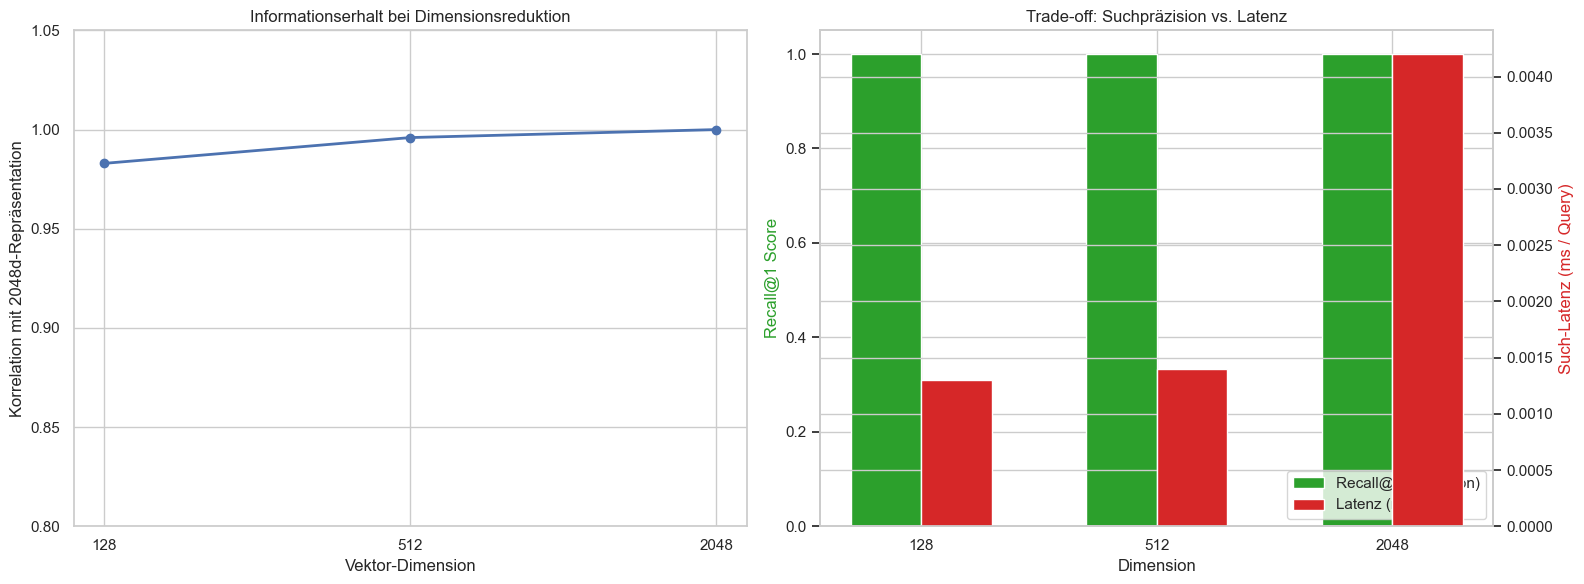

In [47]:
dimensions = [128, 512, 2048]
results = []

for dim in dimensions:
    res = evaluate_dimension(
        dim=dim,
        base_emb_full=base_embeddings_2048,
        noisy_emb_full=noisy_embeddings_2048,
        ground_truth_ids=df_noisy['ground_truth_id'].tolist()
    )
    results.append(res)
        
results_df = pd.DataFrame(results)
print("\n--- Evaluationsergebnisse ---")
print(results_df.to_string(index=False))

plot_results(results_df)

## Referenzen

Kusupati, A., Bhatt, G., Rege, A., Wallingford, M., Sinha, A., Ramanujan, V., … Farhadi, A. (2022). Matryoshka representation learning. Proceedings of the 36th International Conference on Neural Information Processing Systems. Presented at the New Orleans, LA, USA. Red Hook, NY, USA: Curran Associates Inc.

Günther, M., Sturua, S., Akram, M. K., Mohr, I., Ungureanu, A., Wang, B., … Xiao, H. (2025). jina-embeddings-v4: Universal Embeddings for Multimodal Multilingual Retrieval. arXiv [Cs.AI]. Retrieved from http://arxiv.org/abs/2506.18902